# Visualization and personas

PCA and UMAP for a visual comparison of the three algorithms, then a final hybrid segmentation: K-Means' 3-cluster base with DBSCAN's outlier flag layered on top as a 4th, higher-priority segment (see notebook 03 for why K-Means' "high value" cluster quietly absorbs most of the true whales).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
import umap

plt.style.use("seaborn-v0_8-whitegrid")

X = pd.read_parquet("../data/processed/rfm_features_scaled.parquet")
raw = pd.read_parquet("../data/processed/rfm_features.parquet")
labels = pd.read_parquet("../data/processed/cluster_labels.parquet")
print(X.shape, raw.shape, labels.shape)

g:\DS_Practice\Machine_Learning_Practice\Ecommerce_Segmentation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(5852, 6) (5852, 6) (5852, 3)


## 1. PCA

Explained variance ratio: [0.47030787 0.18736646]
Cumulative: 0.6576743319058986


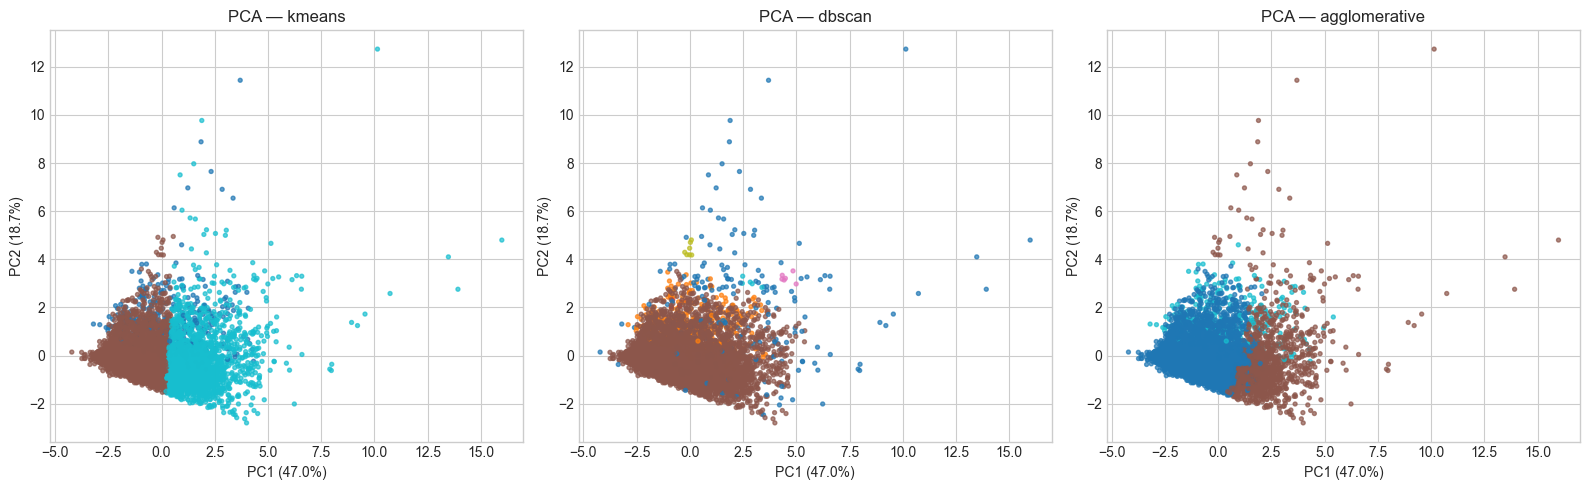

In [2]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, algo in zip(axes, ["kmeans", "dbscan", "agglomerative"]):
    lab = labels[algo].values
    ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c=lab, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(f"PCA \u2014 {algo}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

Only ~66% of variance is captured in 2D, so PCA is a rough sketch here, not a full picture, treat cluster shapes in this view as indicative, not definitive. Notice the DBSCAN panel: outliers (typically plotted as a distinct color) scatter along the edges rather than sitting inside a cluster blob, that's the intended behavior, not a modeling failure.

## 2. UMAP

g:\DS_Practice\Machine_Learning_Practice\Ecommerce_Segmentation\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


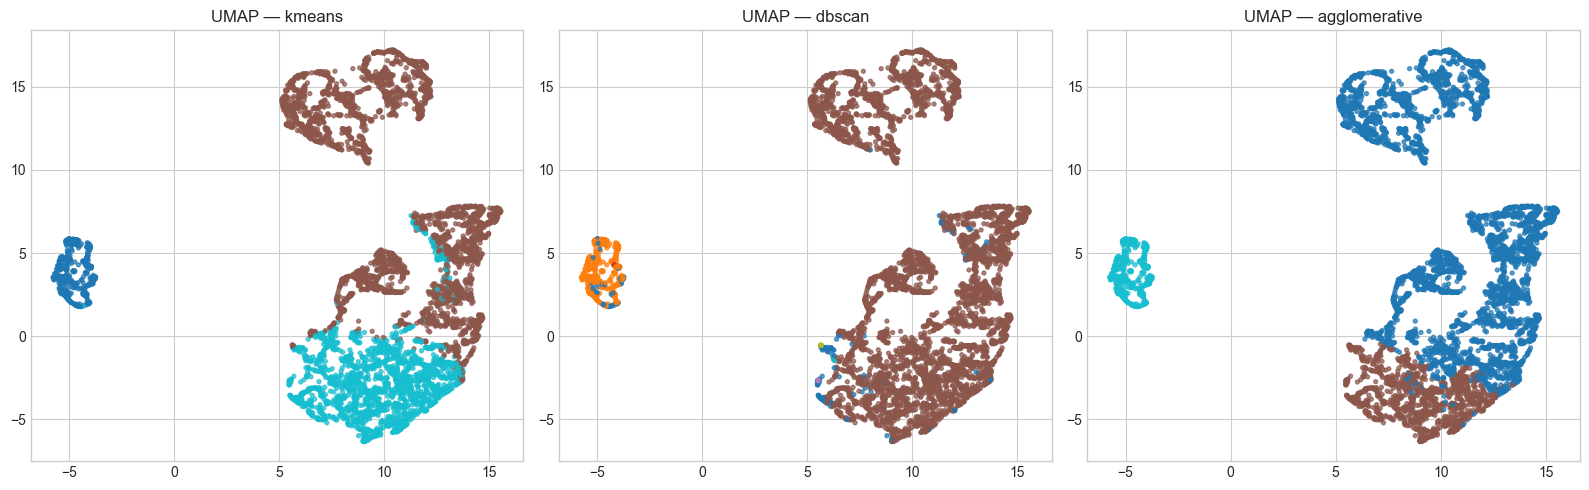

In [3]:
reducer = umap.UMAP(random_state=42)
umap_coords = reducer.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, algo in zip(axes, ["kmeans", "dbscan", "agglomerative"]):
    lab = labels[algo].values
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1], c=lab, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(f"UMAP \u2014 {algo}")
plt.tight_layout()
plt.show()

UMAP separates the clusters more sharply than PCA (expected, it preserves local neighborhood structure rather than global linear variance), which makes it the better figure for the README/portfolio writeup.

## 3. Final segmentation: K-Means base + DBSCAN outlier flag

K-Means cluster 2 ("active, high spend") contains 108 of DBSCAN's 190 flagged outliers. The true whales are hiding inside it, pulling its average up without being distinguishable from a merely-good customer. Pulling the DBSCAN-noise customers out into their own segment first, then labeling what's left by K-Means cluster, gives more honest, actionable groups.

In [4]:
KMEANS_NAMES = {
    0: "International",
    1: "Lapsed Low-Value",
    2: "Active High-Value Core",
}

final_segment = np.where(
    labels["dbscan"] == -1,
    "VIP Outlier",
    labels["kmeans"].map(KMEANS_NAMES),
)
persona_df = raw.copy()
persona_df["segment"] = final_segment
persona_df["segment"].value_counts()

segment
Lapsed Low-Value          3279
Active High-Value Core    1930
International              453
VIP Outlier                190
Name: count, dtype: int64

In [5]:
summary = persona_df.groupby("segment").agg(
    n_customers=("recency", "size"),
    avg_recency_days=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_basket_size=("avg_basket_size", "mean"),
    pct_international=("is_international", lambda s: s.mean() * 100),
).round(1)

rev = persona_df.groupby("segment")["monetary"].sum()
summary["pct_of_total_revenue"] = (rev / rev.sum() * 100).round(1)
summary = summary.sort_values("pct_of_total_revenue", ascending=False)
summary

,n_customers,avg_recency_days,avg_frequency,avg_monetary,avg_basket_size,pct_international,pct_of_total_revenue
segment,,,,,,,
Active High-Value Core,1930,56.1,11.8,4909.7,24.9,0.0,54.5
VIP Outlier,190,206.2,25.4,27002.2,59.1,34.2,29.5
Lapsed Low-Value,3279,288.2,2.1,563.5,18.0,0.0,10.6
International,453,174.7,4.3,2038.0,22.2,100.0,5.3


## 4. Personas

Fill in the exact numbers from the `summary` table above once you've run this on your machine (they should match the exploration run: 190 / 1,930 / 3,279 / 453 customers respectively), the table below is the narrative to build the README section from.

**1. VIP Outliers** (190 customers, 3.2% of base, ~29.5% of revenue)
Avg spend £27,002, avg 25 orders, but avg recency ~206 days (not always the most recent buyers). These are DBSCAN-flagged density outliers, too big/unusual to belong to any "normal" cluster. *Action: dedicated account manager / white-glove outreach, not a generic email campaign, losing even one of these customers has an outsized revenue impact.*

**2. Active High-Value Core** (~1,930 customers, ~80% of remaining revenue)
Avg recency 61 days, avg 13 orders, avg spend £6,826, frequent, recent, reliable. *Action: loyalty/rewards program to protect this segment and nudge toward VIP tier.*

**3. Lapsed Low-Value** (~3,279 customers, largest group by count, smallest by revenue)
Avg recency 290 days, avg 2 orders, avg spend £586. *Action: low-cost win-back email with a discount; don't over-invest here given the low historical value.*

**4. International** (~453 customers, 100% international)
Avg recency 177 days, avg 5 orders, avg spend £2,987, meaningfully lower frequency than the domestic active core. *Action: investigate shipping cost/time or currency friction as a possible driver; localized campaigns.

In [6]:
OUT_PATH = Path("../reports")
OUT_PATH.mkdir(parents=True, exist_ok=True)
summary.to_csv(OUT_PATH / "segment_summary.csv")
persona_df[["segment"]].to_parquet("../data/processed/final_segments.parquet")
print("Saved segment summary and final assignments.")

Saved segment summary and final assignments.
